# SSME Health Monitoring — Example Workflow


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import helpers

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_theme(style='whitegrid')

---
## a) Load data

The `data/` folder contains two CSV files:
- `Table_Nominal_Rid.csv` — 3 000 steady-state operating points, 26 sensors
- `Table_Failures_3sigma_26Sensori.csv` — 28 failure scenarios, same 26 sensors + a `Failure` label column

`helpers.load_nominal` keeps only the 26 sensor columns and drops any NaN/inf row.  
`helpers.load_failures` keeps all columns (including `Failure`) and drops NaN/inf rows.

In [24]:
df_nom = helpers.load_nominal('data/Table_Nominal_Rid.csv')
df_fail = helpers.load_failures('data/Table_Failures_3sigma_26Sensori.csv')

print(f'Nominal  : {df_nom.shape[0]:>5} rows × {df_nom.shape[1]} sensors')
print(f'Failures : {df_fail.shape[0]:>5} rows × {df_fail.shape[1]} columns')
print(f'\nFailure classes ({df_fail["Failure"].nunique()} total):')
print(df_fail['Failure'].value_counts().to_string())

Nominal  :  3000 rows × 26 sensors
Failures : 24060 rows × 27 columns

Failure classes (28 total):
Failure
Riduzione Iniettori Tot FPB              1600
Riduzione Iniettori Tot OPB              1599
Riduzione Iniettori Tot CC               1588
MOV Leakage                               964
OPOV Leakage                              964
Manifold LOX Leakage                      963
Hot Gases Leakage                         950
MFV Leakage                               932
MCC Cooling Leakage                       921
FPOV Leakage                              915
Apertura Anomala OPOV                     829
Riduzione Area Ingresso LPFTP Turbine     800
Riduzione Area Ingresso HPFTP Turbine     800
Riduzione Area Ingresso LPOTP Turbine     800
Apertura Anomala FPOV                     779
MCC Cooling Occlusione                    772
Riduzione Efficienza HPOTP Pump           772
Riduzione Efficienza HPOTP Turbine        762
Riduzione Efficienza HPFTP Pump           751
Riduzione Efficienz

In [25]:
# Quick look at the first rows of each table
print('--- Nominal (first 3 rows) ---')
display(df_nom.head(3))

print('\n--- Failures (first 3 rows) ---')
display(df_fail.head(3))

--- Nominal (first 3 rows) ---


,Pc,HPFTP_w,HPOTP_w,LPFTP_w,LPOTP_w,PBOBP_w,Pc_FPB,Pc_OPB,MFV_m,MOV_m,...,Man_MCC_COOL_Pres,HPFTP_p_pump_out,HPOTP_p_pump_out,LPFTP_p_pump_out,LPOTP_p_pump_out,PBOBP_p_pump_out,HPFTP_T_turb_inlet,HPOTP_T_turb_inlet,LPFTP_T_turb_inlet,LPOTP_T_turb_inlet
0,193.57,43911,27099,29062,4097.1,27099,372.44,345.54,73.918,379.12,...,218.29,409.919,291.135,34.3451,18.6768,542.446,927.332,618.412,411.795,105.096
1,194.79,44405,27366,29159,4146.8,27366,376.62,349.78,74.207,381.31,...,219.82,413.960,297.807,34.0756,19.0869,552.751,944.433,625.803,414.508,105.244
2,193.89,44272,27319,29139,4140.4,27319,374.59,347.92,74.176,378.83,...,218.71,412.335,296.020,34.1359,19.0326,549.471,939.793,619.669,412.782,106.073



--- Failures (first 3 rows) ---


,Pc,HPFTP_w,HPOTP_w,LPFTP_w,LPOTP_w,PBOBP_w,Pc_FPB,Pc_OPB,MFV_m,MOV_m,...,HPFTP_p_pump_out,HPOTP_p_pump_out,LPFTP_p_pump_out,LPOTP_p_pump_out,PBOBP_p_pump_out,HPFTP_T_turb_inlet,HPOTP_T_turb_inlet,LPFTP_T_turb_inlet,LPOTP_T_turb_inlet,Failure
0,194.82,44150.0,27538.0,29001.0,4173.0,27538.0,374.78,350.98,73.001,385.03,...,412.286,301.939,33.8328,19.2390,558.417,940.063,652.236,424.295,104.587,FPOV Leakage
1,190.99,43577.0,27206.0,28805.0,4116.0,27206.0,365.63,342.10,72.377,375.97,...,402.550,291.016,33.5589,18.7160,539.900,916.890,623.844,427.390,107.196,FPOV Leakage
2,190.83,43451.0,27118.0,29061.0,4101.9,27118.0,364.33,340.55,72.579,375.07,...,400.635,289.643,34.3273,18.6551,537.484,916.428,625.341,412.331,106.885,FPOV Leakage


---
## b) Scaling and nominal statistics

We use `StandardScaler` (zero mean, unit variance) fitted **only on the nominal training split**.  
The same scaler is then applied to the failure data — no re-fitting on failures.

After scaling:
- `mu_scaled` ≈ 0 for all sensors (by construction)
- `sigma_scaled` ≈ 1 for all sensors (by construction)
- The **physical** mean and std are stored in `scaler.mean_` and `scaler.scale_`

In [26]:
# Train/test split of nominal data (80/20)
df_nom_train, df_nom_test = train_test_split(df_nom, test_size=0.2, random_state=42)

# Fit scaler on training nominal data only
scaler = helpers.fit_scaler(df_nom_train)

# Scale all sets
X_nom_train = helpers.scale(df_nom_train, scaler)
X_nom_test  = helpers.scale(df_nom_test,  scaler)
X_fail      = helpers.scale(df_fail,      scaler)

print(f'Training set : {X_nom_train.shape}')
print(f'Test set     : {X_nom_test.shape}')
print(f'Failure set  : {X_fail.shape}')

Training set : (2400, 26)
Test set     : (600, 26)
Failure set  : (24060, 26)


In [27]:
# Physical mean and standard deviation of each sensor (from the scaler)
stats = pd.DataFrame({
    'sensor': helpers.SENSOR_NAMES,
    'mean'  : scaler.mean_,
    'std'   : scaler.scale_,
})
display(stats.set_index('sensor').style.format('{:.4g}'))

,mean,std
sensor,,
Pc,194.1,0.841
HPFTP_w,4.428e+04,140.3
HPOTP_w,2.728e+04,93.35
LPFTP_w,2.915e+04,91.35
LPOTP_w,4133,16.78
PBOBP_w,2.728e+04,93.35
Pc_FPB,375,1.876
Pc_OPB,348.5,1.867
MFV_m,74.2,0.3383


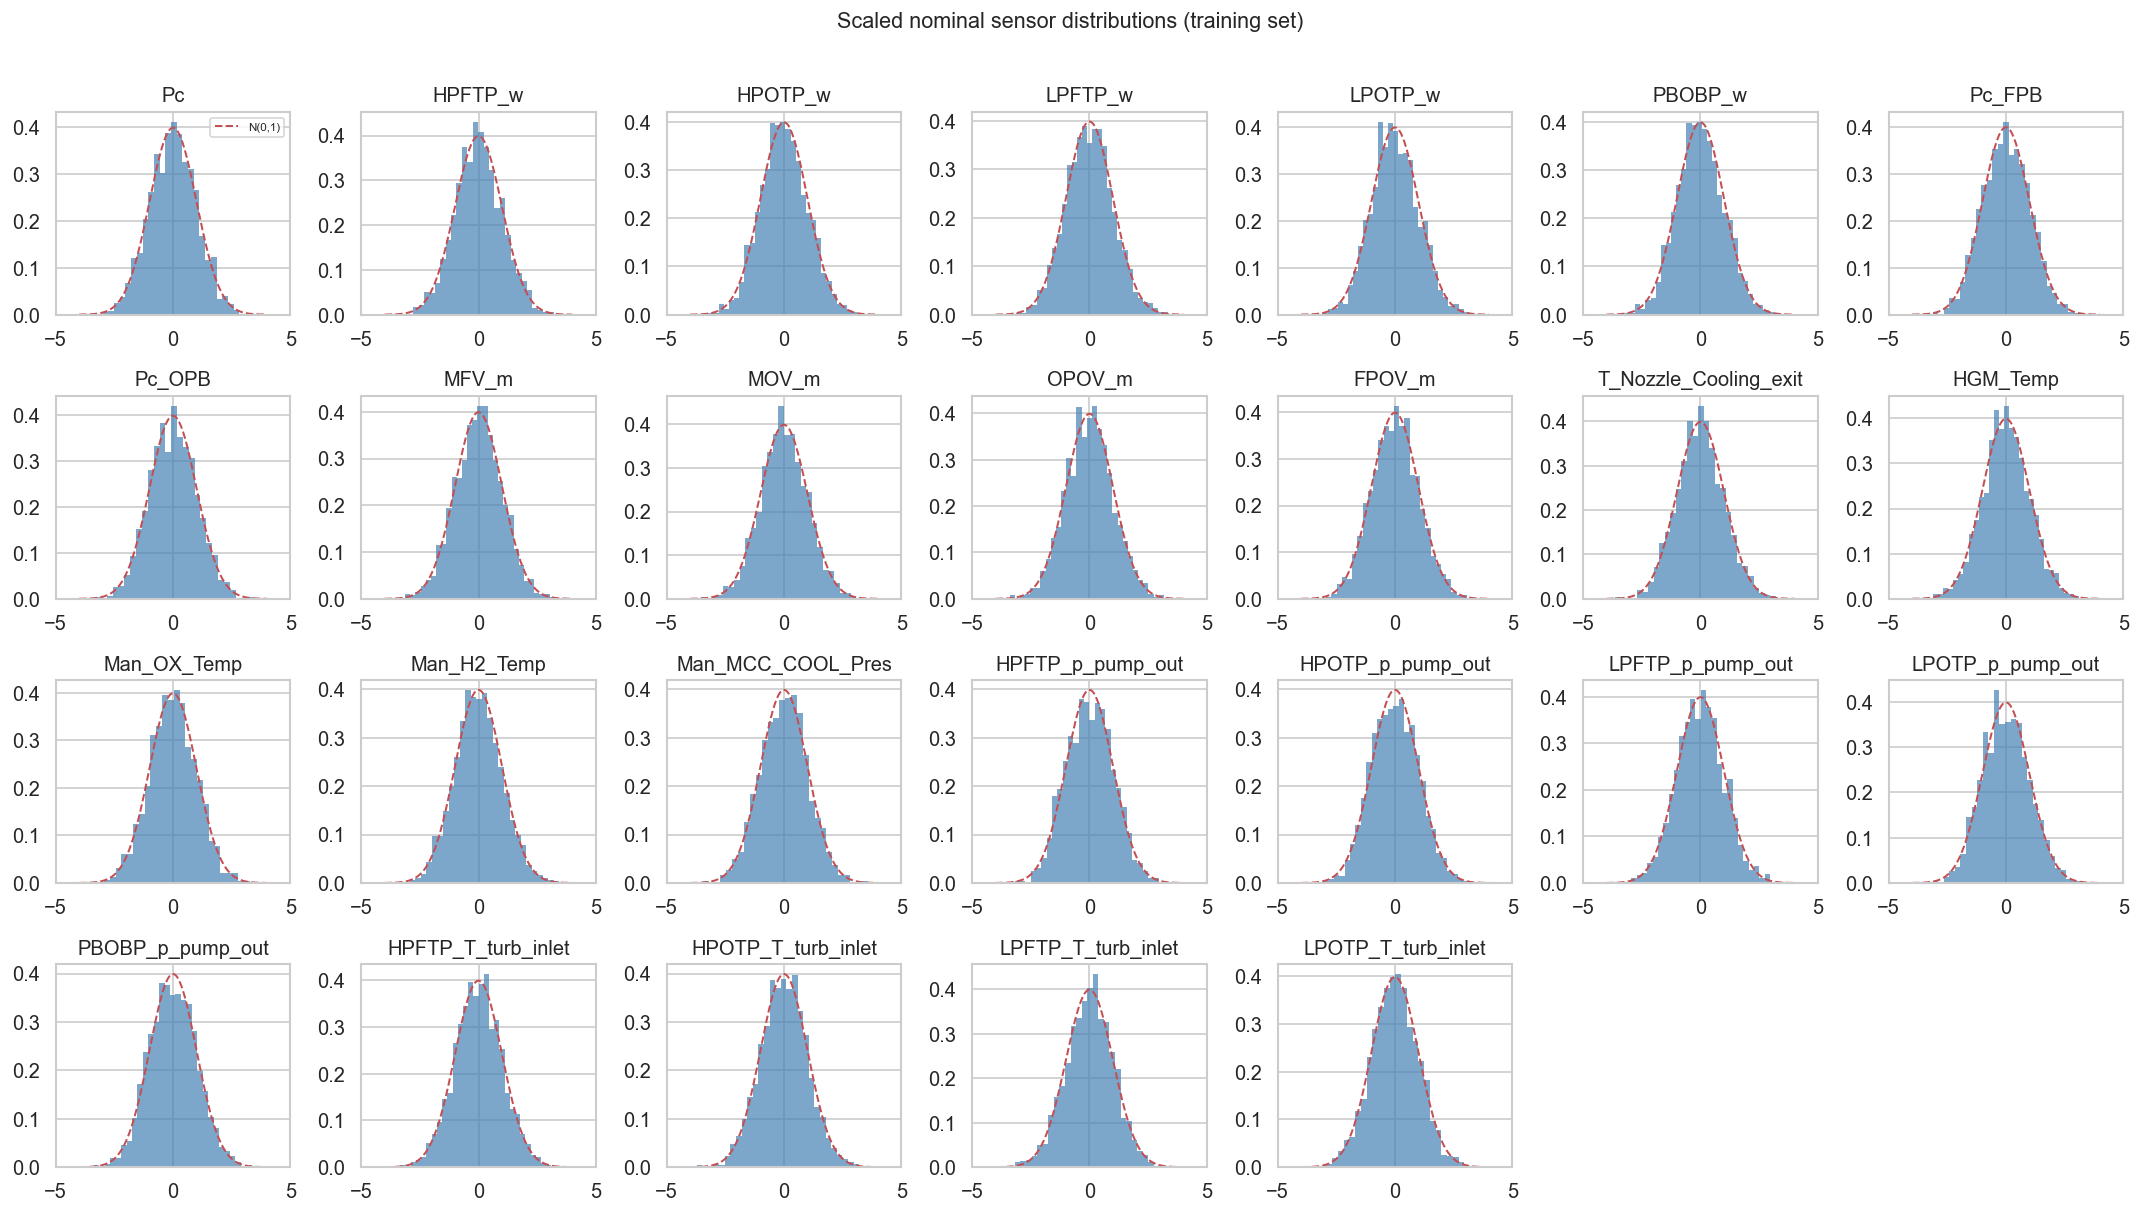

In [33]:
# Distribution of scaled sensor values on the nominal training set
# Each column should look like N(0, 1) after scaling
fig, axes = plt.subplots(4, 7, figsize=(18, 10), sharey=False)
axes = axes.ravel()

x_ref = np.linspace(-4, 4, 200)
gauss = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x_ref**2)

for i, name in enumerate(helpers.SENSOR_NAMES):
    ax = axes[i]
    ax.hist(X_nom_train[:, i], bins=30, density=True, color='steelblue', alpha=0.7, edgecolor='none')
    ax.plot(x_ref, gauss, 'r--', lw=1.2, label='N(0,1)')
    ax.set_title(name, fontsize=12)
    ax.tick_params(labelsize=12)
    ax.set_xlim(-5, 5)

# Hide unused subplots (26 sensors, 28 slots)
for j in range(len(helpers.SENSOR_NAMES), len(axes)):
    axes[j].set_visible(False)

axes[0].legend(fontsize=7)
fig.suptitle('Scaled nominal sensor distributions (training set)', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

---
## c) Mahalanobis distance

The **Mahalanobis distance** measures how many standard deviations a point is from the nominal distribution, accounting for sensor correlations:

$$d_M(\mathbf{x}) = \sqrt{(\mathbf{x} - \boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu})}$$

Steps:
1. Estimate $\boldsymbol{\mu}$ and $\boldsymbol{\Sigma}^{-1}$ from **nominal training data** (using [LedoitWolf](https://scikit-learn.org/stable/modules/generated/sklearn.covariance.LedoitWolf.html) for a robust covariance estimate)
2. Choose a **detection threshold** as the 99th percentile of training distances
3. Any new point exceeding the threshold is flagged as anomalous

In [29]:
# 1. Fit Mahalanobis model on nominal training data
mu, precision = helpers.fit_mahalanobis(X_nom_train)

# 2. Compute distances
d_train = helpers.mahalanobis_distances(X_nom_train, mu, precision)
d_test  = helpers.mahalanobis_distances(X_nom_test,  mu, precision)
d_fail  = helpers.mahalanobis_distances(X_fail,      mu, precision)

# 3. Detection threshold (99th percentile of training distances)
threshold = helpers.detection_threshold(d_train, percentile=99.0)

print(f'Nominal train  — mean: {d_train.mean():.2f}, std: {d_train.std():.2f}, max: {d_train.max():.2f}')
print(f'Nominal test   — mean: {d_test.mean():.2f},  std: {d_test.std():.2f},  max: {d_test.max():.2f}')
print(f'Failures       — mean: {d_fail.mean():.2f}, std: {d_fail.std():.2f}, max: {d_fail.max():.2f}')
print(f'\nDetection threshold (99th pct of train): {threshold:.2f}')

Nominal train  — mean: 3.12, std: 0.75, max: 13.88
Nominal test   — mean: 3.10,  std: 0.69,  max: 5.38
Failures       — mean: 945.69, std: 980.39, max: 6385.22

Detection threshold (99th pct of train): 4.96


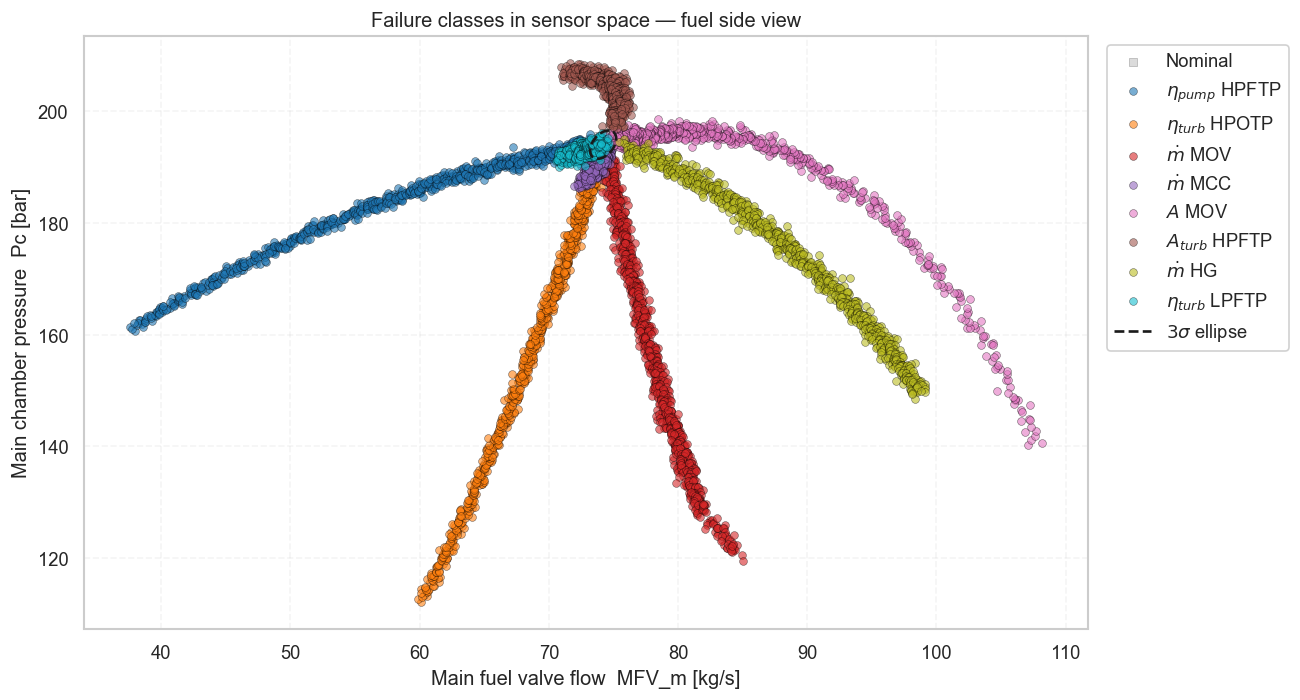

In [30]:
# Same 8 failure classes, colors and legend labels as in figure3.py.
# 'csv' maps to the Italian class name used in Table_Failures_3sigma_26Sensori.csv.
CLASSES_CONFIG = {
    'HPFTP_Pump_Eta':         {'csv': 'Riduzione Efficienza HPFTP Pump',      'color': '#1f77b4', 'label': r'$\eta_{pump}$ HPFTP'},
    'HPOTP_Turbine_Eta':      {'csv': 'Riduzione Efficienza HPOTP Turbine',    'color': '#ff7f0e', 'label': r'$\eta_{turb}$ HPOTP'},
    'MOV_Leakage':            {'csv': 'MOV Leakage',                            'color': '#d62728', 'label': r'$\dot{m}$ MOV'},
    'MCC_Cooling_Leakage':    {'csv': 'MCC Cooling Leakage',                    'color': '#9467bd', 'label': r'$\dot{m}$ MCC'},
    'MOV_Pos':                {'csv': 'Apertura Anomala MOV',                   'color': '#e377c2', 'label': r'$A$ MOV'},
    'Rid_Area_HPFTP_Turbine': {'csv': 'Riduzione Area Ingresso HPFTP Turbine', 'color': '#A35950', 'label': r'$A_{turb}$ HPFTP'},
    'Hot_Gases_Leakage':      {'csv': 'Hot Gases Leakage',                      'color': '#bcbd22', 'label': r'$\dot{m}$ HG'},
    'LPFTP_Turbine_Eta':      {'csv': 'Riduzione Efficienza LPFTP Turbine',     'color': '#17becf', 'label': r'$\eta_{turb}$ LPFTP'},
}

# Filter failure table to the 8 selected classes
csv_names   = [cfg['csv'] for cfg in CLASSES_CONFIG.values()]
csv_to_cfg  = {cfg['csv']: cfg for cfg in CLASSES_CONFIG.values()}
df_fail_sub = df_fail[df_fail['Failure'].isin(csv_names)].copy()

# --- Scatter: fuel flow vs chamber pressure ---
sx, sy = 'MFV_m', 'Pc'

nom_xy  = df_nom[[sx, sy]].to_numpy()
fail_xy = df_fail_sub[[sx, sy]].to_numpy()
labels  = df_fail_sub['Failure'].values

mu2  = nom_xy.mean(axis=0)
cov2 = np.cov(nom_xy, rowvar=False)

fig, ax = plt.subplots(figsize=(11, 6))

ax.scatter(nom_xy[::5, 0], nom_xy[::5, 1],
           c='lightgray', marker='s', s=22, alpha=0.8,
           edgecolors='gray', linewidths=0.3, label='Nominal', zorder=1)

for csv_name, cfg in csv_to_cfg.items():
    mask = labels == csv_name
    if not mask.any(): continue
    ax.scatter(fail_xy[mask, 0], fail_xy[mask, 1],
               color=cfg['color'], s=22, alpha=0.6,
               edgecolors='black', linewidths=0.3, label=cfg['label'], zorder=2)

ex, ey = helpers.ellipse_points(mu2, cov2, radius=3)
ax.plot(ex, ey, 'k--', lw=1.6, label=r'$3\sigma$ ellipse', zorder=3)

ax.set_xlabel('Main fuel valve flow  MFV_m [kg/s]')
ax.set_ylabel('Main chamber pressure  Pc [bar]')
ax.set_title('Failure classes in sensor space — fuel side view')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), framealpha=0.9)
ax.grid(True, alpha=0.2, linestyle='--')
fig.tight_layout()
plt.show()

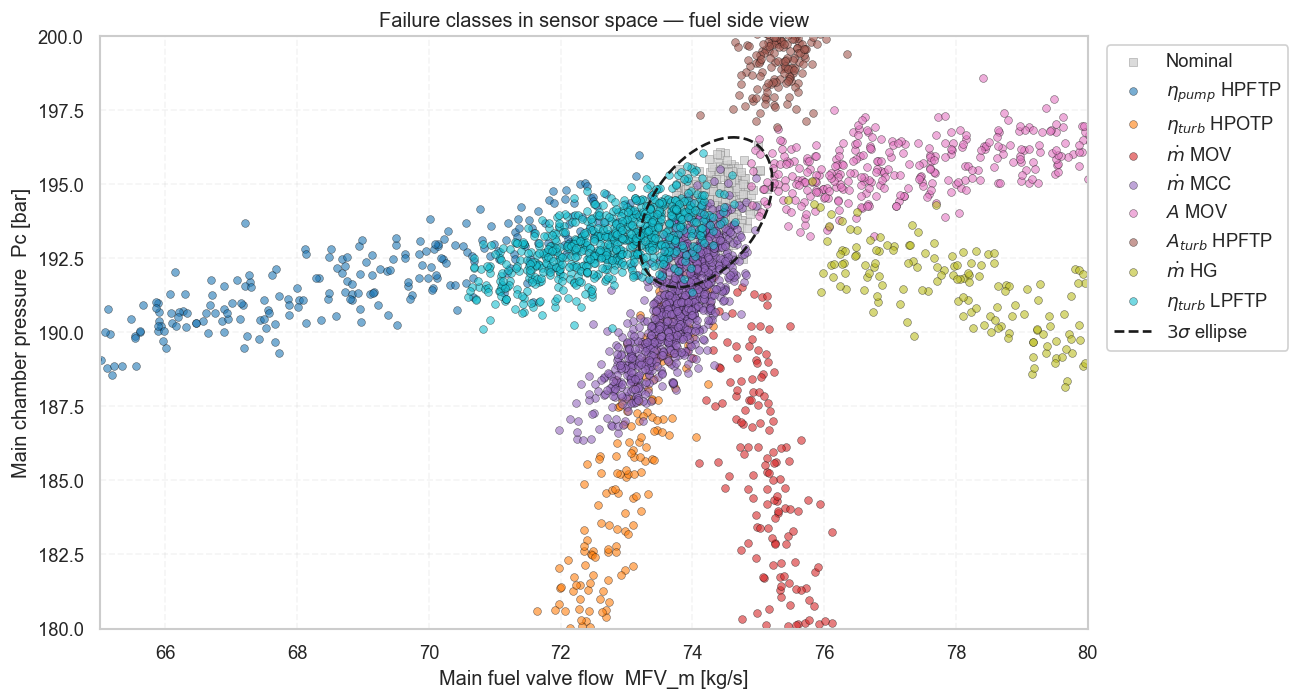

In [31]:

fig, ax = plt.subplots(figsize=(11, 6))

ax.scatter(nom_xy[::5, 0], nom_xy[::5, 1],
           c='lightgray', marker='s', s=22, alpha=0.8,
           edgecolors='gray', linewidths=0.3, label='Nominal', zorder=1)

for csv_name, cfg in csv_to_cfg.items():
    mask = labels == csv_name
    if not mask.any(): continue
    ax.scatter(fail_xy[mask, 0], fail_xy[mask, 1],
               color=cfg['color'], s=22, alpha=0.6,
               edgecolors='black', linewidths=0.3, label=cfg['label'], zorder=2)

ex, ey = helpers.ellipse_points(mu2, cov2, radius=3)
ax.plot(ex, ey, 'k--', lw=1.6, label=r'$3\sigma$ ellipse', zorder=3)
ax.set_xlim(65,80)
ax.set_ylim(180,200)
ax.set_xlabel('Main fuel valve flow  MFV_m [kg/s]')
ax.set_ylabel('Main chamber pressure  Pc [bar]')
ax.set_title('Failure classes in sensor space — fuel side view')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), framealpha=0.9)
ax.grid(True, alpha=0.2, linestyle='--')
fig.tight_layout()
plt.show()